<a href="https://colab.research.google.com/github/Sanjeev1628/ESP32-IoT-WEATHER-station/blob/main/Marine_debris_Colab_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Marine Debris Analysis

**Google Colab-ready cleaned version**

This notebook loads `nasaa.csv`, performs data validation, yearly trend analysis, 10-year linear regression forecasting, seasonal analysis, country-level analysis, and an interactive geographical map.

### How to use
1. Run the setup cell.
2. Upload `nasaa.csv` when prompted.
3. Use **Runtime → Run all**.

> The original notebook contained duplicate cells, example data that replaced the real dataset, missing NumPy imports, and Windows-only shapefile paths. Those issues have been removed.

In [5]:
# 1. Install/import required packages
!pip -q install -U seaborn scikit-learn plotly

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from google.colab import files

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 40.6 MB/s eta 0:00:00
✅ Libraries loaded successfully.


In [6]:
# 2. Upload the real dataset
# Expected file: nasaa.csv

if not os.path.exists('nasaa.csv'):
    print('Please select your nasaa.csv file:')
    uploaded = files.upload()
    if 'nasaa.csv' not in uploaded:
        raise FileNotFoundError(
            "The uploaded file must be named 'nasaa.csv'. Rename it and run this cell again."
        )

print('📄 Dataset found:', os.path.abspath('nasaa.csv'))

Please select your nasaa.csv file:


Saving nasaa.csv to nasaa.csv
📄 Dataset found: /content/nasaa.csv


In [7]:
# 3. Load and validate the dataset

def load_data(file_path='nasaa.csv'):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Convert known date field when available
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Convert debris to numeric when available
    if 'Total_Debris' in df.columns:
        df['Total_Debris'] = pd.to_numeric(df['Total_Debris'], errors='coerce')

    return df

data = load_data()

required = ['Total_Debris']
missing = [c for c in required if c not in data.columns]
if missing:
    raise ValueError(
        f"Missing required column(s): {missing}. Available columns: {list(data.columns)}"
    )

print(f'✅ Loaded {len(data):,} rows and {len(data.columns)} columns.')
print('\nColumns:')
print(list(data.columns))

print('\nFirst 5 rows:')
display(data.head())

✅ Loaded 2,121 rows and 142 columns.

Columns:
['FID', 'Survey_Type', 'Organization', 'Date', 'Survey_Year', 'Country', 'State', 'County', 'Survey_ID', 'MDMAP_ID__', 'Shoreline_Name', 'Latitude_Start', 'Longitude_Start', 'Latitude_End', 'Longitude_End', 'Slope', 'Width', 'Length', 'Start_Time', 'End_Time', 'Time_of_Low_Tide', 'Database_Season', 'Season', 'Date_of_Previous_Survey', 'Days_since_last_survey', 'Storm_Activity', 'Current_Weather', 'Number_of_Persons_Assisting', 'Large_Items_', 'Debris_Behind_Back_Barrier_', 'Datasheet_Version', 'Notes', 'Photos', 'Plastic', 'Plastic___Flux', 'Hard_Plastic_Fragments', 'Hard_Plastic_Fragments___Flux', 'Foamed_Plastic_Fragments', 'Foamed_Plastic_Fragments___Flux', 'Filmed_Plastic_Fragments', 'Filmed_Plastic_Fragments___Flux', 'Food_Wrappers', 'Food_Wrappers___Flux', 'Plastic_Beverage_Bottles', 'Plastic_Beverage_Bottles___Flux', 'Other_Jugs_Containers', 'Other_Jugs_Containers___Flux', 'Bottle_Container_Caps', 'Bottle_Container_Caps___Flux', 'Ci

,FID,Survey_Type,Organization,Date,Survey_Year,Country,State,County,Survey_ID,MDMAP_ID__,...,Rope_Net_Pieces__non_nylon____F,Fabric_Pieces,Fabric_Pieces___Flux,Cloth_Fabric_Other,Cloth_Fabric_Other___Flux,Unclassified,Unclassified___Flux,Total_Debris,Total_Debris___Flux,Debris_Description
0,1,Accumulation,Dauphin Island Sea Lab,2015-07-30,Year 1,United States,AL,Mobile,6004,218,...,0.0,0.0,0.0,0.0,2.0,0.000019,143.0,0.001333,unclassified other - shotshells,NaN
1,2,Accumulation,Dauphin Island Sea Lab,2015-05-09,Year 1,United States,AL,Mobile,5763,216,...,0.0,0.0,0.0,0.0,5.0,0.000025,58.0,0.000296,Unclassified other - Ceramic:4 unclassified o...,NaN
2,3,Accumulation,Dauphin Island Sea Lab,2015-04-09,Year 1,United States,LA,St. Bernard,5899,240,...,0.0,0.0,0.0,0.0,1.0,0.000009,63.0,0.000560,PLastic other - whistle unclassified other - s...,NaN
3,4,Accumulation,OCNMS,2015-07-31,Year 4,United States,WA,Clallam,3865,100,...,0.0,0.0,0.0,0.0,0.0,0.000000,14.0,0.000059,".07kg other glass = light bulb intact, other p...",NaN
4,5,Accumulation,Dauphin Island Sea Lab,2015-05-09,Year 1,United States,AL,Mobile,5767,217,...,0.0,0.0,0.0,0.0,3.0,0.000015,111.0,0.000570,unclassified other - ceramic tile,NaN


In [16]:
# 4. Basic data quality report

print('Dataset shape:', data.shape)
print('\nData types:')
print(data.dtypes)

print('\nMissing values:')
print(data.isna().sum())

print('\nNumerical summary:')
display(data.describe(include='all').transpose())

Dataset shape: (2121, 142)

Data types:
FID                      int64
Survey_Type             object
Organization            object
Date                    object
Survey_Year             object
                        ...   
Unclassified           float64
Unclassified___Flux    float64
Total_Debris           float64
Total_Debris___Flux     object
Debris_Description      object
Length: 142, dtype: object

Missing values:
FID                       0
Survey_Type               0
Organization              0
Date                      0
Survey_Year               0
                       ... 
Unclassified              0
Unclassified___Flux       0
Total_Debris              0
Total_Debris___Flux     597
Debris_Description     1689
Length: 142, dtype: int64

Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FID,2121.0,NaN,NaN,NaN,1061.0,612.424281,1.0,531.0,1061.0,1591.0,2121.0
Survey_Type,2121,1,Accumulation,2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Organization,2121,55,OCNMS,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,2121,971,2016/08/19 00:00:00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survey_Year,2121,7,Year 1,733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Unclassified,2121.0,NaN,NaN,NaN,0.855732,7.455587,0.0,0.0,0.0,0.0,211.0
Unclassified___Flux,2121.0,NaN,NaN,NaN,83.852915,269.623475,0.0,0.0,14.0,64.0,6205.0
Total_Debris,2121.0,NaN,NaN,NaN,132.603221,437.607507,0.0,0.000163,0.001517,60.0,6916.0
Total_Debris___Flux,1524,1325,Unclassified other - shotshells,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# 5. Prepare year information

if 'Date' in data.columns:
    data['Year'] = data['Date'].dt.year
elif 'Year' in data.columns:
    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
else:
    raise ValueError("The dataset needs either a 'Date' or 'Year' column for yearly analysis.")

data['Total_Debris'] = pd.to_numeric(data['Total_Debris'], errors='coerce')

analysis_data = data.dropna(subset=['Year', 'Total_Debris']).copy()
analysis_data['Year'] = analysis_data['Year'].astype(int)

if analysis_data.empty:
    raise ValueError('No valid rows remain after cleaning Year and Total_Debris.')

print(f'✅ {len(analysis_data):,} valid rows available for analysis.')

✅ 2,121 valid rows available for analysis.


Yearly totals:


,Year,Total_Debris
0,2015,1.469081
1,2016,74842.785913
2,2017,138690.061421
3,2018,67717.115580


10-year forecast:


,Year,Predicted_Debris
0,2019,137061.411750
1,2020,163760.833250
2,2021,190460.254751
3,2022,217159.676251
4,2023,243859.097751
5,2024,270558.519252
6,2025,297257.940752
7,2026,323957.362253
8,2027,350656.783753
9,2028,377356.205254


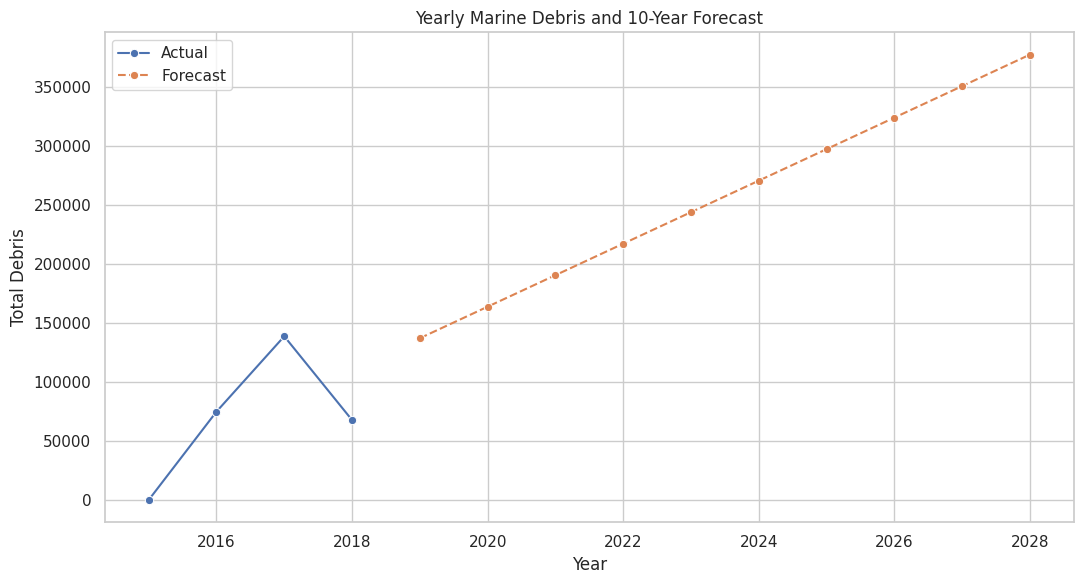

In [9]:
# 6. Yearly marine debris analysis and 10-year forecast

yearly_data = (
    analysis_data.groupby('Year', as_index=False)['Total_Debris']
    .sum()
    .sort_values('Year')
)

print('Yearly totals:')
display(yearly_data)

if len(yearly_data) >= 2:
    model = LinearRegression()
    X = yearly_data[['Year']]
    y = yearly_data['Total_Debris']
    model.fit(X, y)

    future_years = pd.DataFrame({
        'Year': np.arange(
            int(yearly_data['Year'].max()) + 1,
            int(yearly_data['Year'].max()) + 11
        )
    })
    future_years['Predicted_Debris'] = model.predict(future_years[['Year']])

    print('10-year forecast:')
    display(future_years)

    plt.figure(figsize=(11, 6))
    sns.lineplot(data=yearly_data, x='Year', y='Total_Debris', marker='o', label='Actual')
    sns.lineplot(data=future_years, x='Year', y='Predicted_Debris', marker='o', linestyle='--', label='Forecast')
    plt.title('Yearly Marine Debris and 10-Year Forecast')
    plt.xlabel('Year')
    plt.ylabel('Total Debris')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ At least two different years are required for regression forecasting.')

,Month,Total_Debris,Month_Name
0,1,94.152587,January
1,2,74.511418,February
2,3,97.319278,March
3,4,122.558511,April
4,5,138.948762,May
5,6,223.724706,June
6,7,162.574392,July
7,8,148.282966,August
8,9,148.374529,September
9,10,123.130001,October


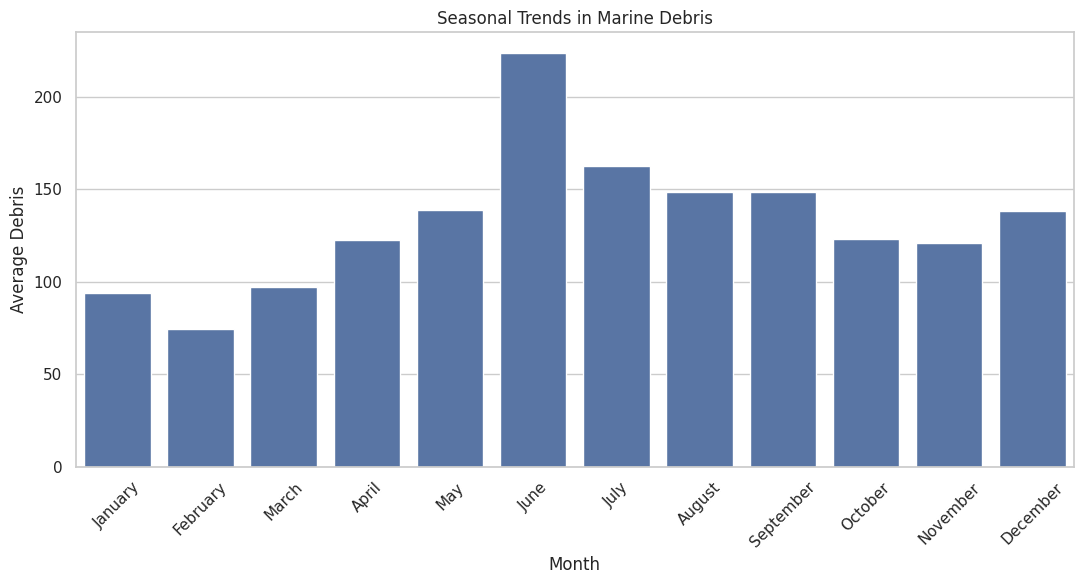

In [11]:
# 7. Seasonal/monthly trend analysis

if 'Date' not in analysis_data.columns:
    print("⚠️ Seasonal analysis requires a valid 'Date' column.")
else:
    seasonal_data = analysis_data.dropna(subset=['Date']).copy()
    seasonal_data['Month'] = seasonal_data['Date'].dt.month

    monthly_data = (
        seasonal_data.groupby('Month', as_index=False)['Total_Debris']
        .mean()
        .sort_values('Month')
    )

    month_names = {i: name for i, name in enumerate(
        ['January','February','March','April','May','June',
         'July','August','September','October','November','December'], 1)
    }
    monthly_data['Month_Name'] = monthly_data['Month'].map(month_names)

    display(monthly_data)

    plt.figure(figsize=(11, 6))
    sns.barplot(data=monthly_data, x='Month_Name', y='Total_Debris')
    plt.title('Seasonal Trends in Marine Debris')
    plt.xlabel('Month')
    plt.ylabel('Average Debris')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

,Country,Total_Debris
7,United States,269615.431415
5,Palau,7504.000000
4,"Micronesia, Federated States of",1689.000000
6,Tonga,1073.000000
2,Ecuador,867.000000
3,Mexico,503.000000
1,Canada,0.000580
0,Bahamas,0.000000


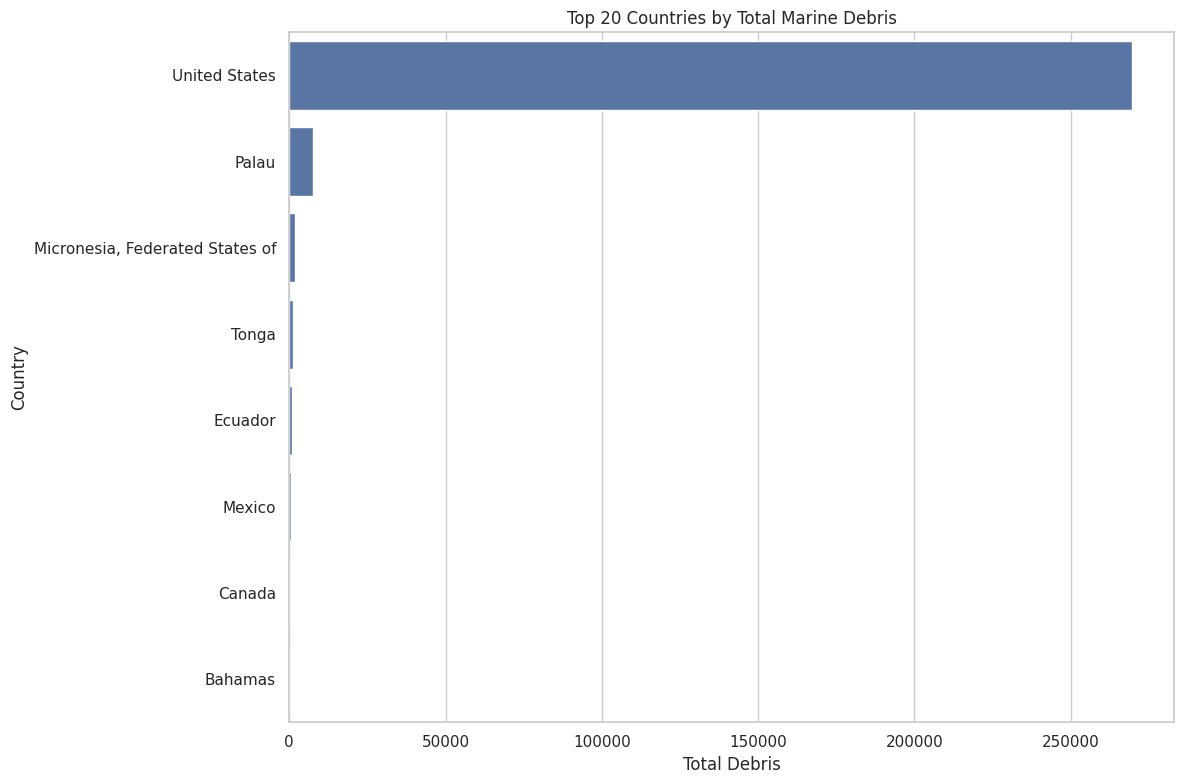

In [10]:
# 8. Country-level marine debris analysis

if 'Country' not in analysis_data.columns:
    print("⚠️ Country analysis skipped because 'Country' is not present.")
else:
    country_data = (
        analysis_data.dropna(subset=['Country'])
        .groupby('Country', as_index=False)['Total_Debris']
        .sum()
        .sort_values('Total_Debris', ascending=False)
    )

    display(country_data)

    plt.figure(figsize=(12, 8))
    plot_data = country_data.head(20)
    sns.barplot(data=plot_data, x='Total_Debris', y='Country')
    plt.title('Top 20 Countries by Total Marine Debris')
    plt.xlabel('Total Debris')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

In [12]:
# 9. Interactive geographical analysis — no shapefile required
# This replaces the original Windows-only E:\... shapefile path.

if 'Country' not in analysis_data.columns:
    print("⚠️ Map skipped because 'Country' is not present.")
else:
    map_data = (
        analysis_data.dropna(subset=['Country'])
        .groupby('Country', as_index=False)['Total_Debris']
        .sum()
    )

    # Plotly's ISO country-name mode avoids needing a local .shp/.dbf/.shx/.prj bundle.
    fig = px.choropleth(
        map_data,
        locations='Country',
        locationmode='country names',
        color='Total_Debris',
        hover_name='Country',
        color_continuous_scale='OrRd',
        title='Geographical Distribution of Marine Debris'
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True),
        margin=dict(l=0, r=0, t=60, b=0)
    )
    fig.show()

In [13]:
# 10. Key findings summary

print('===== MARINE DEBRIS ANALYSIS SUMMARY =====')
print(f'Total records analysed: {len(analysis_data):,}')
print(f'Year range: {analysis_data["Year"].min()} - {analysis_data["Year"].max()}')
print(f'Total recorded debris: {analysis_data["Total_Debris"].sum():,.2f}')

if 'Country' in analysis_data.columns and not country_data.empty:
    top_country = country_data.iloc[0]
    print(f'Top country by recorded debris: {top_country["Country"]} ({top_country["Total_Debris"]:,.2f})')

if len(yearly_data) >= 2:
    slope = model.coef_[0]
    direction = 'increasing' if slope > 0 else 'decreasing' if slope < 0 else 'stable'
    print(f'Linear trend: {direction} ({slope:,.2f} debris units/year)')

print('===========================================')

===== MARINE DEBRIS ANALYSIS SUMMARY =====
Total records analysed: 2,121
Year range: 2015 - 2018
Total recorded debris: 281,251.43
Top country by recorded debris: United States (269,615.43)
Linear trend: increasing (26,699.42 debris units/year)


In [18]:
import pandas as pd

data = pd.read_csv("nasaa.csv")

# Clean column names
data.columns = data.columns.str.strip()

# Exact search
result = data[
    data["Country"].astype(str).str.strip().str.lower().eq("los angeles") &
    data["Debris_Type"].astype(str).str.strip().str.lower().eq("cloth_fabric_other")
]

print("=" * 60)
print("LOS ANGELES — CLOTH_FABRIC_OTHER")
print("=" * 60)

if result.empty:
    print("❌ No cloth_fabric_other records found for Los Angeles.")
else:
    print(f"📍 Location       : Los Angeles")
    print(f"🧵 Debris Type    : cloth_fabric_other")
    print(f"📊 Records Found  : {len(result)}")

    if "Total_Debris" in result.columns:
        print(f"🗑️ Total Debris   : {result['Total_Debris'].sum():,.2f}")
        print(f"📈 Average Debris : {result['Total_Debris'].mean():,.2f}")

    display(result)

KeyError: 'Debris_Type'

In [ ]:
import pandas as pd

data = pd.read_csv("nasaa.csv")

# Clean column names
data.columns = data.columns.str.strip()

print("YOUR CSV COLUMNS:")
print("=" * 50)

for i, col in enumerate(data.columns):
    print(i, "->", col)


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("nasaa.csv")

# Clean column names
data.columns = data.columns.str.strip()

print("Dataset loaded successfully!")
print("Rows:", len(data))
print("Columns:", len(data.columns))


Dataset loaded successfully!
Rows: 2121
Columns: 142


In [21]:
print("Total Records:", len(data))
print("Total Features:", len(data.columns))



Total Records: 2121
Total Features: 142


## Notes
- Keep your real `nasaa.csv`; this notebook never replaces it with sample/demo data.
- If your CSV uses different column names, rename them to `Date`, `Country`, and `Total_Debris` or adjust the column names in the validation cell.
- The map uses Plotly and therefore does **not** require the original Natural Earth shapefile or any Windows `E:\` path.

In [22]:
for i, col in enumerate(data.columns):
    print(i, "->", col)

0 -> FID
1 -> Survey_Type
2 -> Organization
3 -> Date
4 -> Survey_Year
5 -> Country
6 -> State
7 -> County
8 -> Survey_ID
9 -> MDMAP_ID__
10 -> Shoreline_Name
11 -> Latitude_Start
12 -> Longitude_Start
13 -> Latitude_End
14 -> Longitude_End
15 -> Slope
16 -> Width
17 -> Length
18 -> Start_Time
19 -> End_Time
20 -> Time_of_Low_Tide
21 -> Database_Season
22 -> Season
23 -> Date_of_Previous_Survey
24 -> Days_since_last_survey
25 -> Storm_Activity
26 -> Current_Weather
27 -> Number_of_Persons_Assisting
28 -> Large_Items_
29 -> Debris_Behind_Back_Barrier_
30 -> Datasheet_Version
31 -> Notes
32 -> Photos
33 -> Plastic
34 -> Plastic___Flux
35 -> Hard_Plastic_Fragments
36 -> Hard_Plastic_Fragments___Flux
37 -> Foamed_Plastic_Fragments
38 -> Foamed_Plastic_Fragments___Flux
39 -> Filmed_Plastic_Fragments
40 -> Filmed_Plastic_Fragments___Flux
41 -> Food_Wrappers
42 -> Food_Wrappers___Flux
43 -> Plastic_Beverage_Bottles
44 -> Plastic_Beverage_Bottles___Flux
45 -> Other_Jugs_Containers
46 -> Other_

In [23]:
print("Total Marine Debris:", data["Total_Debris"].sum())
print("Average Marine Debris:", data["Total_Debris"].mean())
print("Maximum Marine Debris:", data["Total_Debris"].max())
print("Minimum Marine Debris:", data["Total_Debris"].min())

Total Marine Debris: 281251.431994496
Average Marine Debris: 132.6032211195172
Maximum Marine Debris: 6916.0
Minimum Marine Debris: 0.0


In [24]:
print("Countries:")
display(data["Country"].value_counts())

print("\nStates:")
display(data["State"].value_counts().head(20))

print("\nCounties:")
display(data["County"].value_counts().head(20))

Countries:


,count
Country,
United States,2084
Palau,21
Canada,8
Ecuador,4
"Micronesia, Federated States of",1
Bahamas,1
Mexico,1
Tonga,1



States:


,count
State,
WA,526
CA,384
VA,169
MS,167
TX,155
OR,152
FL,117
HI,109
LA,80



Counties:


,count
County,
Clallam,383
Jackson,167
Sonoma,120
Maui,112
Humboldt,86
Jefferson,81
Mobile,75
Santa Rosa,75
Aransas,66


In [25]:
la = data[
    data["County"].astype(str).str.contains(
        "Los Angeles",
        case=False,
        na=False
    )
]

print("Los Angeles records:", len(la))

display(
    la[
        [
            "Country",
            "State",
            "County",
            "Shoreline_Name",
            "Date",
            "Total_Debris"
        ]
    ].head(20)
)

Los Angeles records: 0


,Country,State,County,Shoreline_Name,Date,Total_Debris


In [26]:
print("=" * 60)
print("LOS ANGELES — CLOTH/FABRIC OTHER")
print("=" * 60)

print("Records:", len(la))

print(
    "Total Cloth/Fabric Other:",
    la["Cloth_Fabric_Other"].fillna(0).sum()
)

print(
    "Average:",
    la["Cloth_Fabric_Other"].fillna(0).mean()
)

print(
    "Maximum in one survey:",
    la["Cloth_Fabric_Other"].fillna(0).max()
)

LOS ANGELES — CLOTH/FABRIC OTHER
Records: 0
Total Cloth/Fabric Other: 0.0
Average: nan
Maximum in one survey: nan


In [27]:
display(
    la[
        [
            "Date",
            "Survey_Year",
            "Shoreline_Name",
            "Cloth_Fabric_Other",
            "Cloth_Fabric_Other___Flux",
            "Total_Debris"
        ]
    ].sort_values(
        "Cloth_Fabric_Other",
        ascending=False
    )
)

,Date,Survey_Year,Shoreline_Name,Cloth_Fabric_Other,Cloth_Fabric_Other___Flux,Total_Debris


In [28]:
display(
    la[
        [
            "Date",
            "Survey_Year",
            "Shoreline_Name",
            "Cloth_Fabric_Other",
            "Cloth_Fabric_Other___Flux",
            "Total_Debris"
        ]
    ].sort_values(
        "Cloth_Fabric_Other",
        ascending=False
    )
)

,Date,Survey_Year,Shoreline_Name,Cloth_Fabric_Other,Cloth_Fabric_Other___Flux,Total_Debris


In [29]:
country = (
    data.groupby("United States")["Total_Debris"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

display(country)

KeyError: 'United States'

In [30]:
country = (
    data.groupby("Country")["Total_Debris"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

display(country)

,count,sum,mean
Country,,,
United States,2084,269615.431415,129.374007
Palau,21,7504.000000,357.333333
"Micronesia, Federated States of",1,1689.000000,1689.000000
Tonga,1,1073.000000,1073.000000
Ecuador,4,867.000000,216.750000
Mexico,1,503.000000,503.000000
Canada,8,0.000580,0.000072
Bahamas,1,0.000000,0.000000


In [31]:
plastic = data["Plastic"].fillna(0).sum()
total = data["Total_Debris"].fillna(0).sum()

percentage = (plastic / total) * 100

print(f"Plastic percentage: {percentage:.2f}%")

Plastic percentage: 143.32%


In [32]:
print("Weather categories:")
print(data["Current_Weather"].value_counts(dropna=False))

Weather categories:
Current_Weather
Sunny                                         192
sunny                                          37
Cloudy                                         34
NaN                                            34
Sunny, Calm                                    33
                                             ... 
clear, below freezing in shade, calm winds      1
5% cloud cover                                  1
63 F  Clear                                     1
100 % cloud cover, moderate offshore winds      1
40% Clouds                                      1
Name: count, Length: 1282, dtype: int64


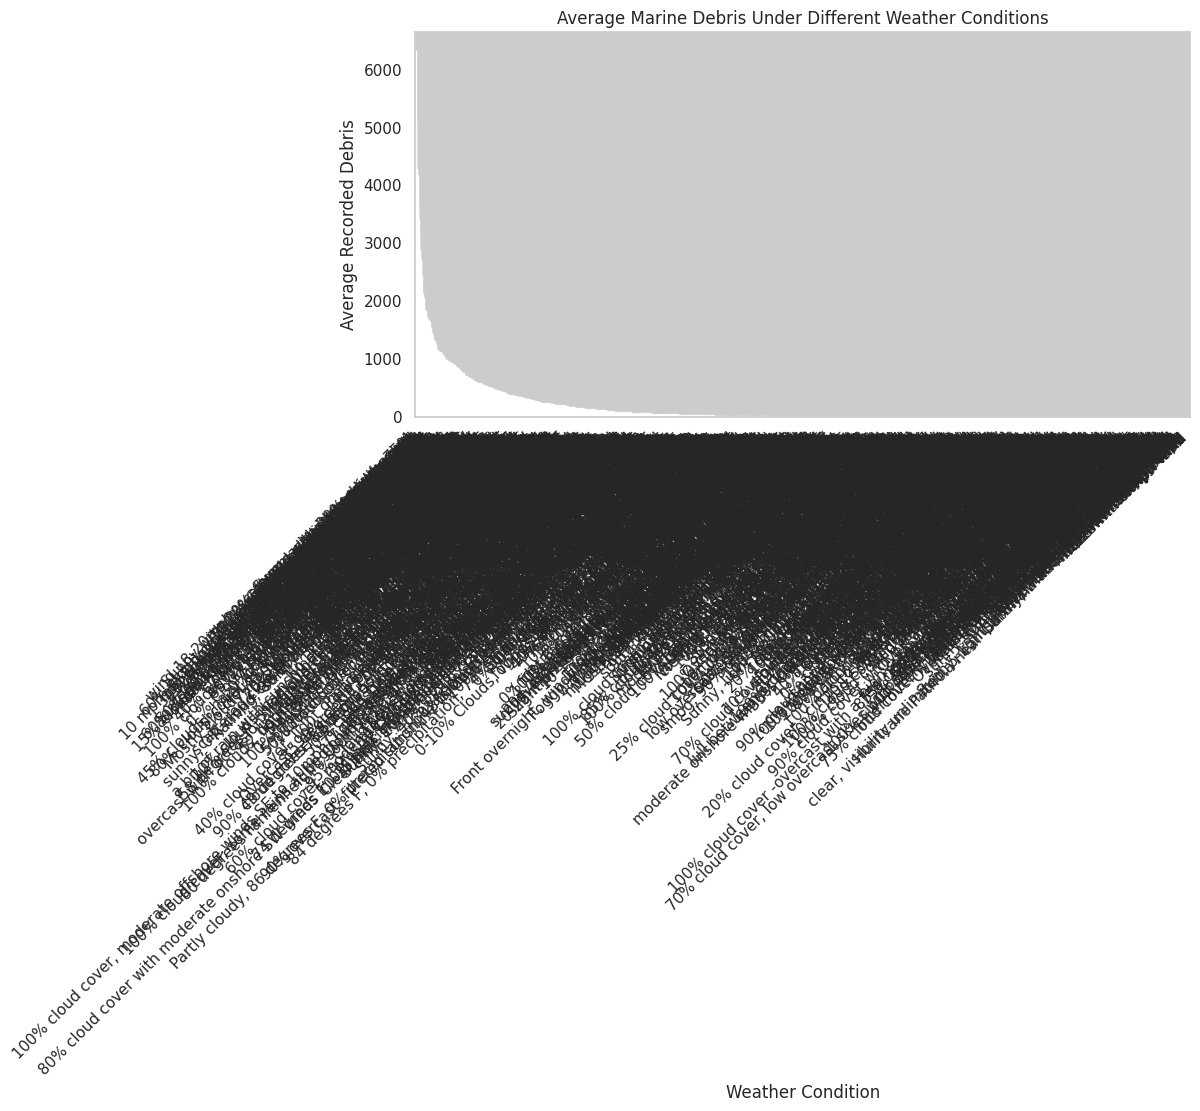

In [33]:
weather_avg = (
    data.groupby("Current_Weather")["Total_Debris"]
    .mean()
    .sort_values(ascending=False)
)

weather_avg.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Marine Debris Under Different Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Average Recorded Debris")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()